In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "SeoulBikeData.csv",
    encoding="unicode_escape"
)

df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8760
Columns: 14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [5]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [8]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

Understand the target variable


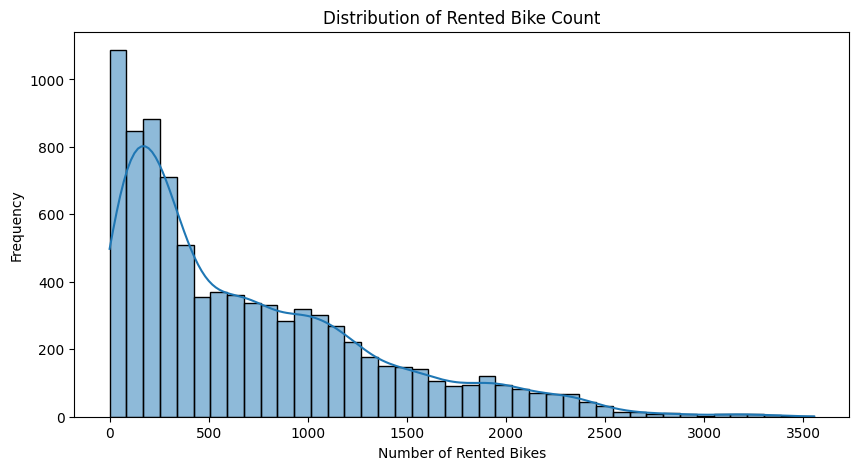

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Rented Bike Count"], kde=True)

plt.title("Distribution of Rented Bike Count")
plt.xlabel("Number of Rented Bikes")
plt.ylabel("Frequency")

plt.show()

In [10]:
df["Rented Bike Count"].describe()

,Rented Bike Count
count,8760.000000
mean,704.602055
std,644.997468
min,0.000000
25%,191.000000
50%,504.500000
75%,1065.250000
max,3556.000000


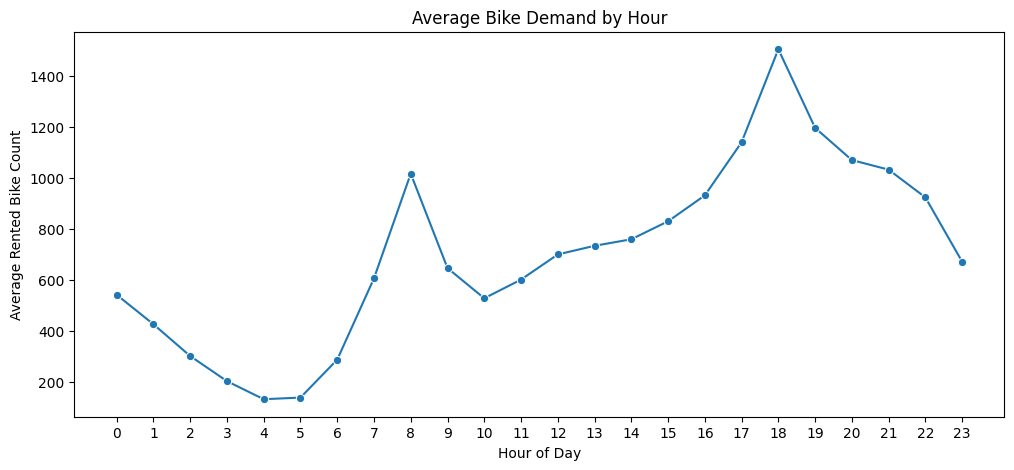

In [11]:
hourly_demand = df.groupby("Hour")["Rented Bike Count"].mean()

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_demand.index,
    y=hourly_demand.values,
    marker="o"
)

plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")

plt.xticks(range(24))
plt.show()

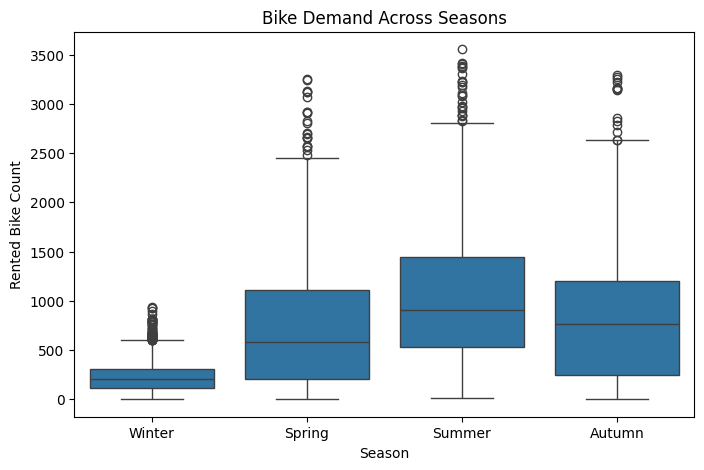

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Seasons",
    y="Rented Bike Count"
)

plt.title("Bike Demand Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rented Bike Count")

plt.show()

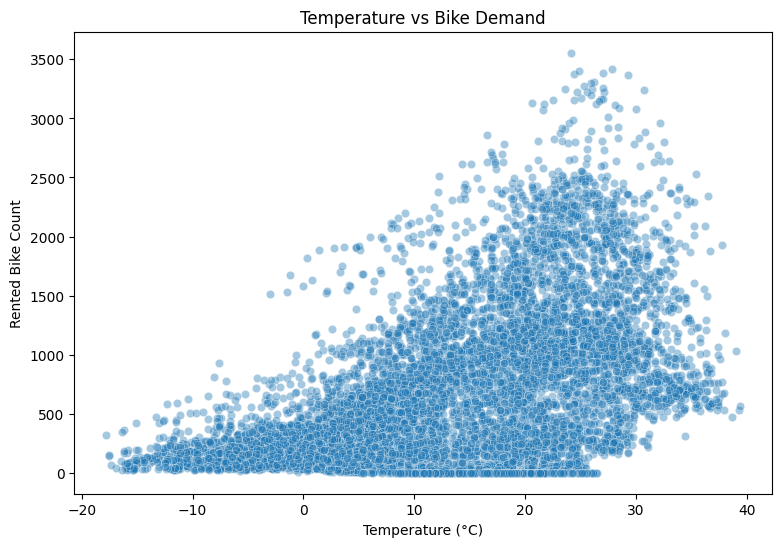

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Temperature(°C)",
    y="Rented Bike Count",
    alpha=0.4
)

plt.title("Temperature vs Bike Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rented Bike Count")

plt.show()

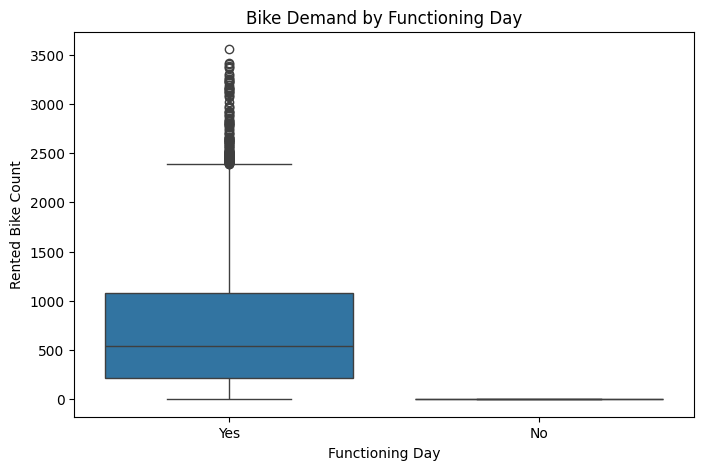

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Functioning Day",
    y="Rented Bike Count"
)

plt.title("Bike Demand by Functioning Day")
plt.xlabel("Functioning Day")
plt.ylabel("Rented Bike Count")

plt.show()

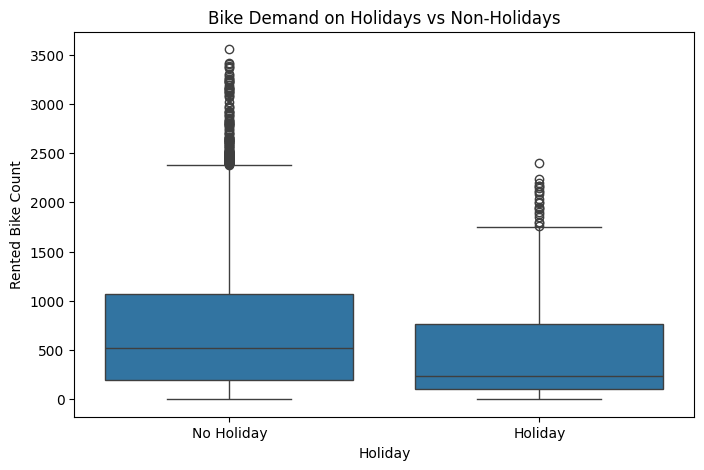

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Holiday",
    y="Rented Bike Count"
)

plt.title("Bike Demand on Holidays vs Non-Holidays")
plt.xlabel("Holiday")
plt.ylabel("Rented Bike Count")

plt.show()

In [16]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)'],
      dtype='object')

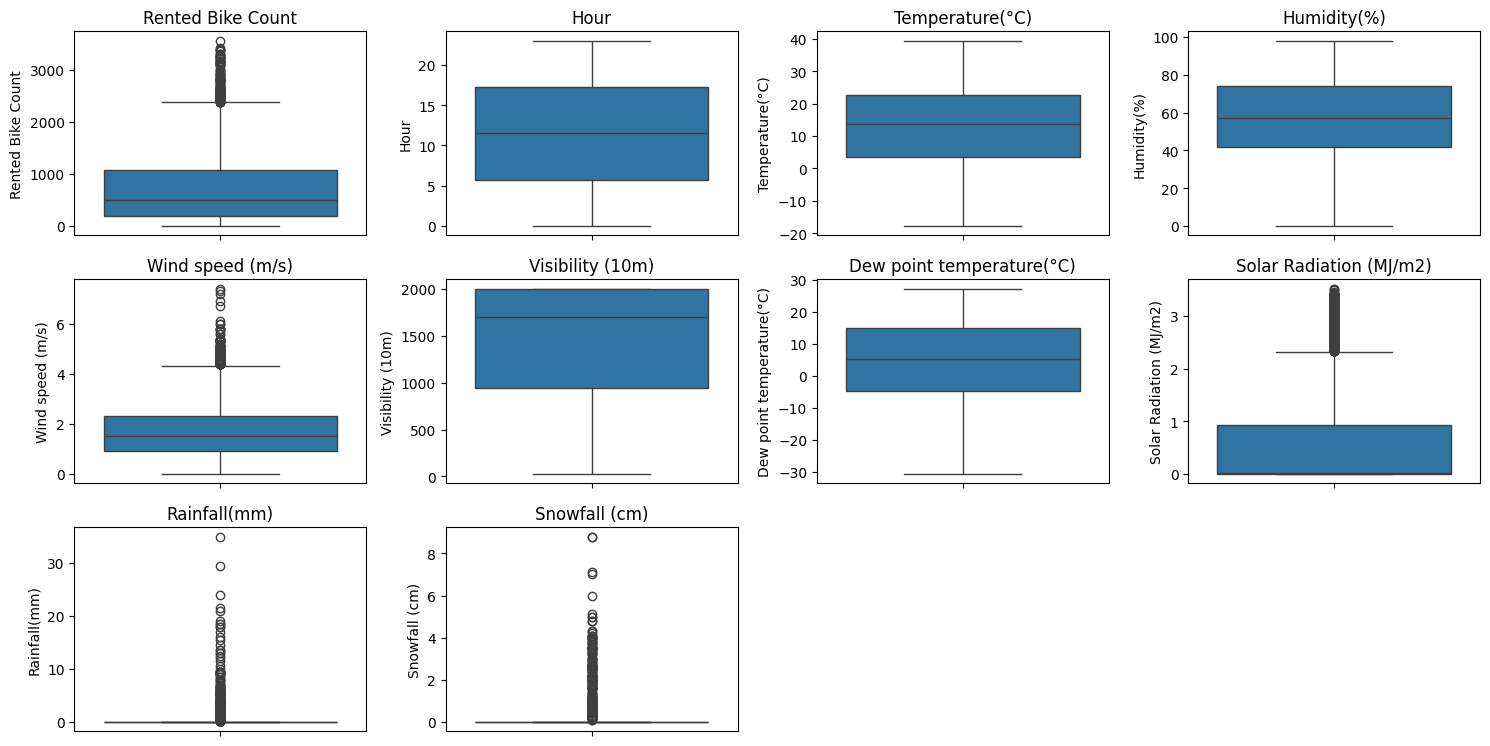

In [17]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} potential outliers")

Rented Bike Count: 158 potential outliers
Hour: 0 potential outliers
Temperature(°C): 0 potential outliers
Humidity(%): 0 potential outliers
Wind speed (m/s): 161 potential outliers
Visibility (10m): 0 potential outliers
Dew point temperature(°C): 0 potential outliers
Solar Radiation (MJ/m2): 641 potential outliers
Rainfall(mm): 528 potential outliers
Snowfall (cm): 443 potential outliers


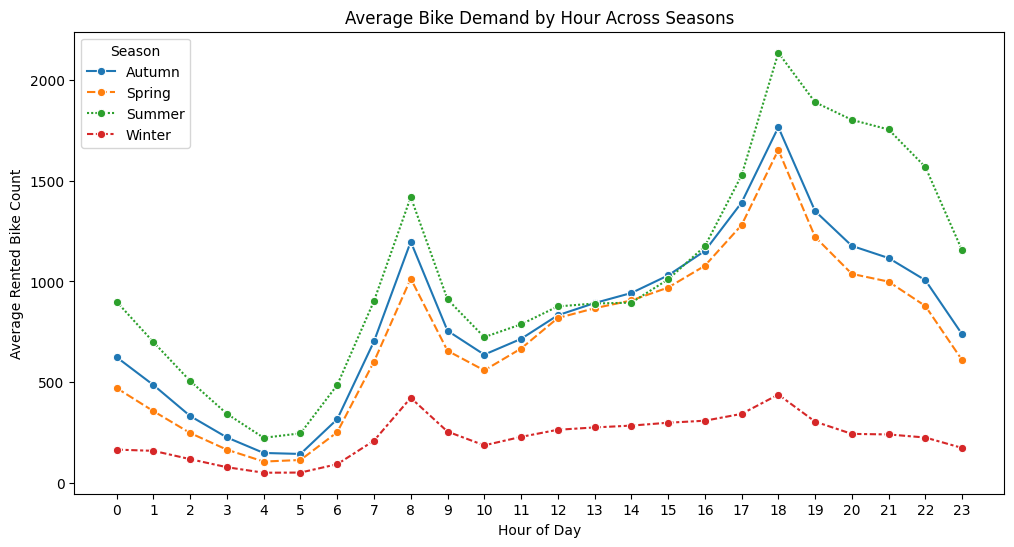

In [19]:
season_hour = df.pivot_table(
    values="Rented Bike Count",
    index="Hour",
    columns="Seasons",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=season_hour, marker="o")

plt.title("Average Bike Demand by Hour Across Seasons")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(24))
plt.legend(title="Season")
plt.show()

In [20]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["DayOfWeek"] = df["Date"].dt.day_name()

df["IsWeekend"] = df["Date"].dt.dayofweek >= 5

df[["Date", "DayOfWeek", "IsWeekend"]].head()

,Date,DayOfWeek,IsWeekend
0,2017-12-01,Friday,False
1,2017-12-01,Friday,False
2,2017-12-01,Friday,False
3,2017-12-01,Friday,False
4,2017-12-01,Friday,False


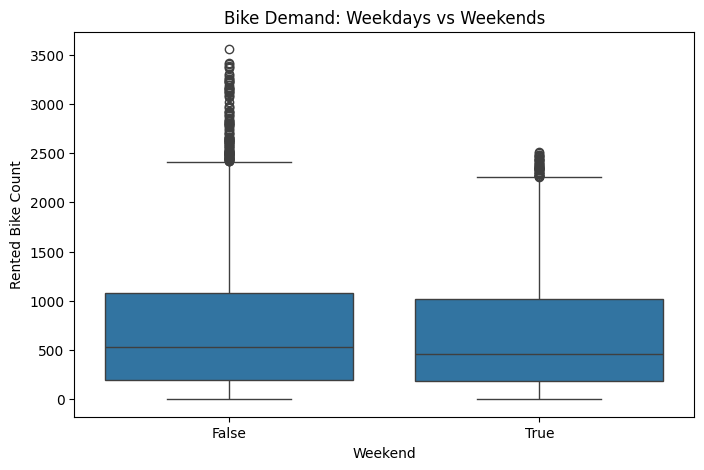

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="IsWeekend",
    y="Rented Bike Count"
)

plt.title("Bike Demand: Weekdays vs Weekends")
plt.xlabel("Weekend")
plt.ylabel("Rented Bike Count")
plt.show()

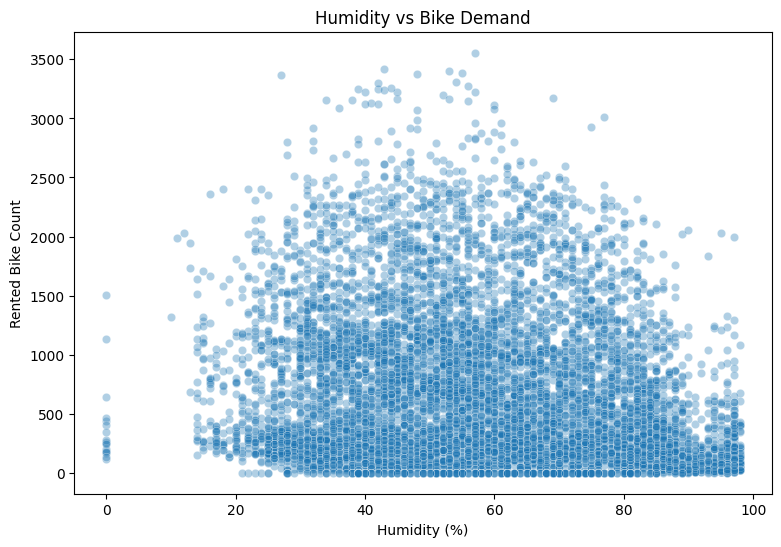

In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Humidity(%)",
    y="Rented Bike Count",
    alpha=0.35
)

plt.title("Humidity vs Bike Demand")
plt.xlabel("Humidity (%)")
plt.ylabel("Rented Bike Count")
plt.show()

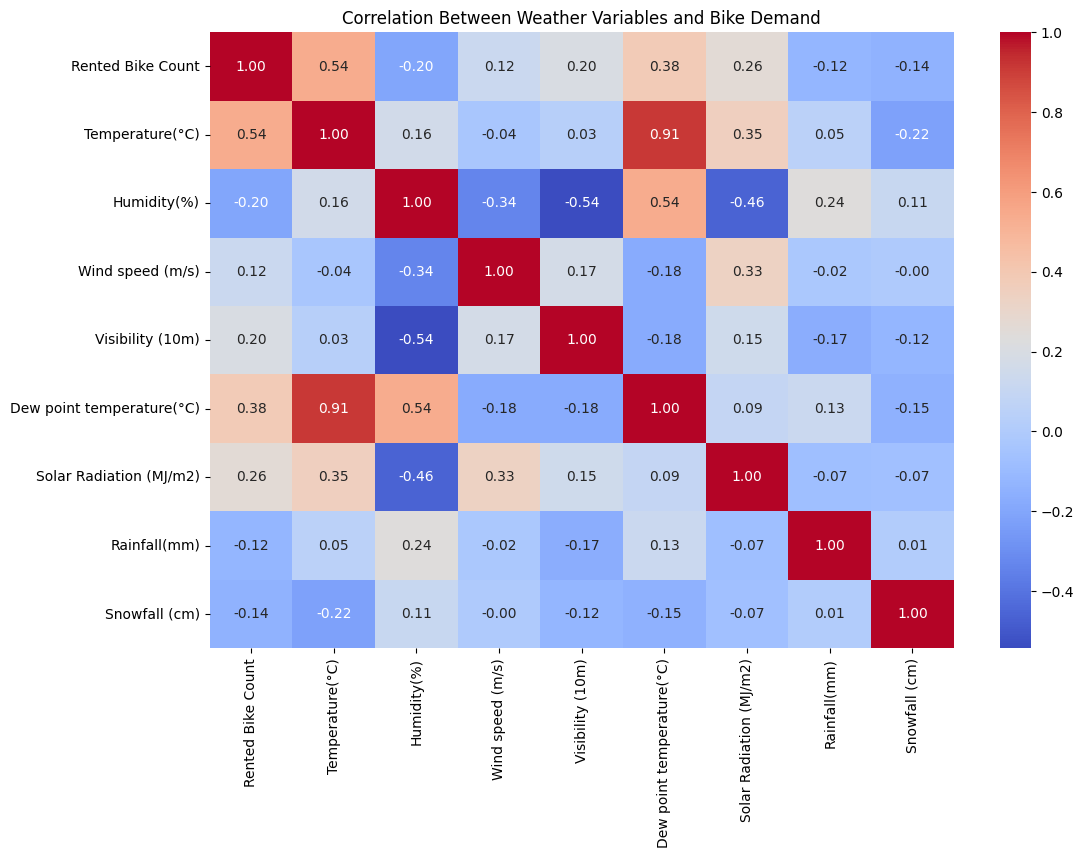

In [23]:
weather_cols = [
    "Rented Bike Count",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[weather_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Weather Variables and Bike Demand")
plt.show()

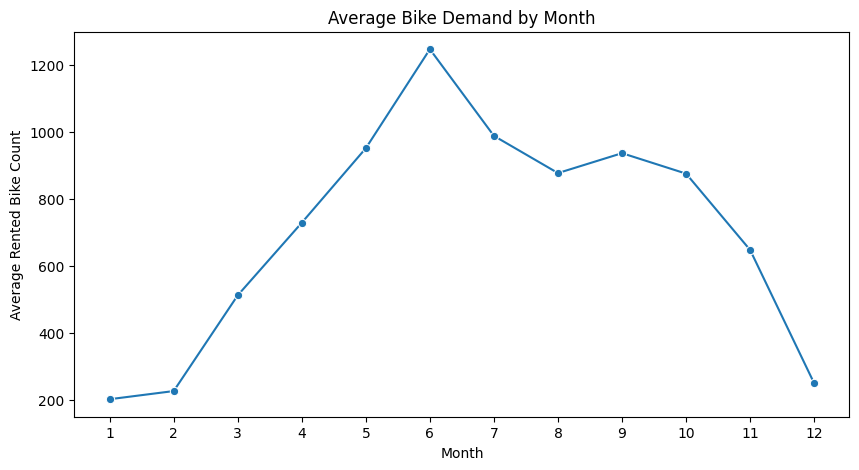

In [24]:
df["Month"] = df["Date"].dt.month

monthly_demand = df.groupby("Month")["Rented Bike Count"].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_demand.index,
    y=monthly_demand.values,
    marker="o"
)

plt.title("Average Bike Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(1, 13))
plt.show()

EDA & Feature extraction

In [25]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df[["Date", "Year", "Month", "Day", "DayOfWeek"]].head()

,Date,Year,Month,Day,DayOfWeek
0,2017-12-01,2017,12,1,4
1,2017-12-01,2017,12,1,4
2,2017-12-01,2017,12,1,4
3,2017-12-01,2017,12,1,4
4,2017-12-01,2017,12,1,4


In [26]:
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df[["DayOfWeek", "IsWeekend"]].head(10)

,DayOfWeek,IsWeekend
0,4,0
1,4,0
2,4,0
3,4,0
4,4,0
5,4,0
6,4,0
7,4,0
8,4,0
9,4,0


In [27]:
df.columns.tolist()

['Date',
 'Rented Bike Count',
 'Hour',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Seasons',
 'Holiday',
 'Functioning Day',
 'DayOfWeek',
 'IsWeekend',
 'Month',
 'Year',
 'Day']

In [28]:
target = "Rented Bike Count"

X = df.drop(columns=[target, "Date"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8760, 17)
y shape: (8760,)


In [29]:
X.dtypes

,0
Hour,int64
Temperature(°C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature(°C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64
Snowfall (cm),float64
Seasons,object


In [30]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nNumber of features:", X.shape[1])
print("Number of samples:", X.shape[0])

Features:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day', 'DayOfWeek', 'IsWeekend', 'Month', 'Year', 'Day']

Target:
Rented Bike Count

Number of features: 17
Number of samples: 8760


Chronological Train/Test Split

In [31]:
df = df.sort_values("Date").reset_index(drop=True)

In [32]:
target = "Rented Bike Count"
X = df.drop(columns=[target, "Date"])
y = df[target]


In [33]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7008, 17)
X_test : (1752, 17)
y_train: (7008,)
y_test : (1752,)


In [34]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

print("Categorical:")
print(categorical_cols)

print("\nNumerical:")
print(numerical_cols)

Categorical:
['Seasons', 'Holiday', 'Functioning Day']

Numerical:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'DayOfWeek', 'IsWeekend', 'Month', 'Year', 'Day']


Build Preprocessing Pipeline

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [38]:
print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nAfter preprocessing:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

Before preprocessing:
X_train: (7008, 17)
X_test : (1752, 17)

After preprocessing:
X_train_processed: (7008, 22)
X_test_processed : (1752, 22)


In [39]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 336.13203135566954
RMSE: 460.6121896373225
R²  : 0.43599997146716485


MAE - average prediction error of how many bikes rented ,
RMSE - large errors how strongly penilize ,
R2_score - model target variablity explaining  , closest to 1 means better fit

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

In [42]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 223.90598173515983
RMSE: 321.772350784119
R²  : 0.724763695062167


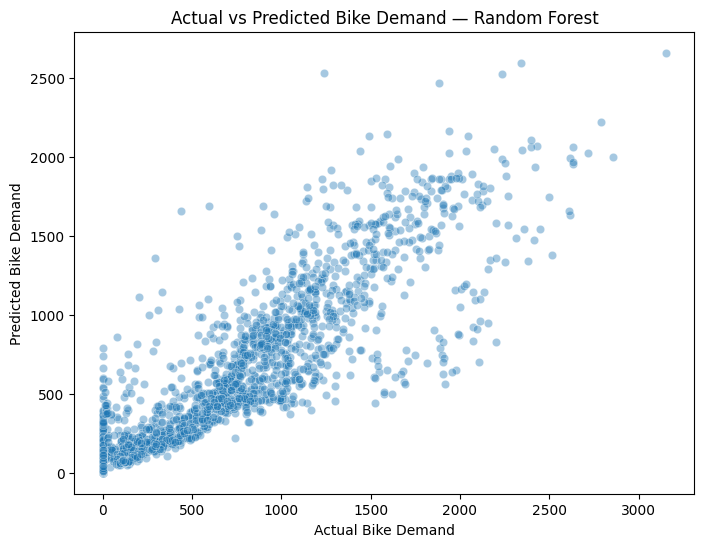

In [43]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.4
)

plt.xlabel("Actual Bike Demand")
plt.ylabel("Predicted Bike Demand")
plt.title("Actual vs Predicted Bike Demand — Random Forest")

plt.show()

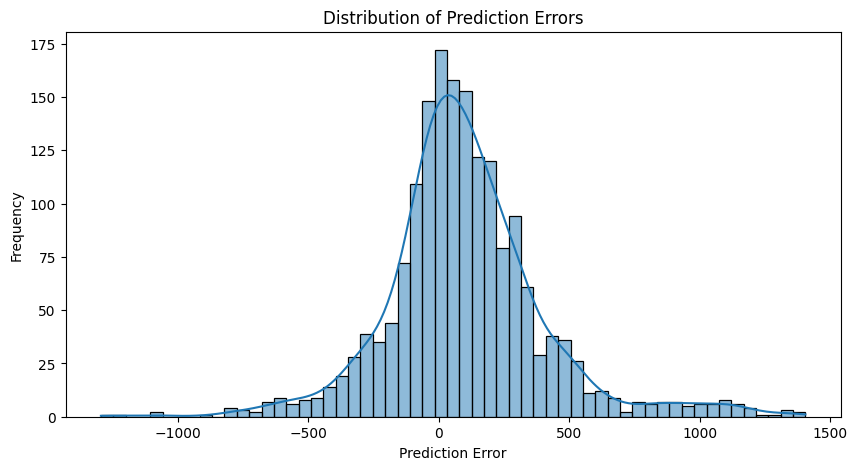

In [44]:
errors = y_test - y_pred_rf

plt.figure(figsize=(10, 5))

sns.histplot(errors, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [45]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,num__Temperature(°C),0.381811
0,num__Hour,0.284376
6,num__Solar Radiation (MJ/m2),0.085497
2,num__Humidity(%),0.069307
7,num__Rainfall(mm),0.043550
5,num__Dew point temperature(°C),0.025361
9,num__DayOfWeek,0.020855
10,num__IsWeekend,0.013837
21,cat__Functioning Day_Yes,0.013570
11,num__Month,0.013180


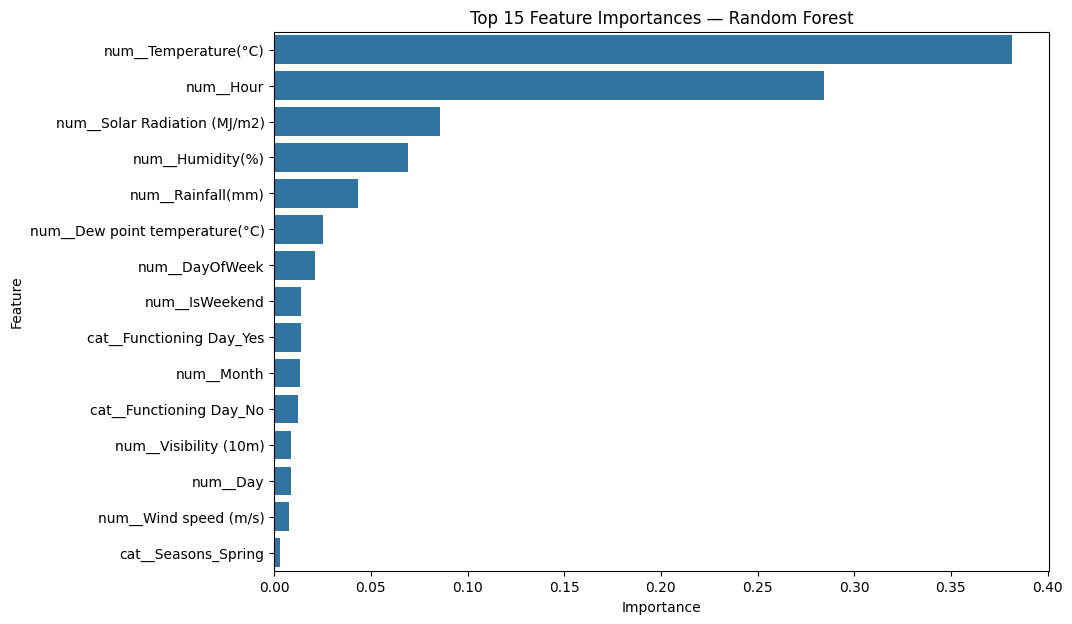

In [46]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [47]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count}")

Rented Bike Count: 158
Hour: 0
Temperature(°C): 0
Humidity(%): 0
Wind speed (m/s): 161
Visibility (10m): 0
Dew point temperature(°C): 0
Solar Radiation (MJ/m2): 641
Rainfall(mm): 528
Snowfall (cm): 443
DayOfWeek: 0
IsWeekend: 0
Month: 0
Year: 744
Day: 0


In [48]:
outlier_cols = [
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} potential outliers")

Temperature(°C): 0 potential outliers
Humidity(%): 0 potential outliers
Wind speed (m/s): 161 potential outliers
Visibility (10m): 0 potential outliers
Dew point temperature(°C): 0 potential outliers
Solar Radiation (MJ/m2): 641 potential outliers
Rainfall(mm): 528 potential outliers
Snowfall (cm): 443 potential outliers


In [49]:
df.loc[
    df["Rainfall(mm)"] > df["Rainfall(mm)"].quantile(0.75) +
    1.5 * (
        df["Rainfall(mm)"].quantile(0.75) -
        df["Rainfall(mm)"].quantile(0.25)
    ),
    ["Date", "Hour", "Rainfall(mm)", "Rented Bike Count"]
].head(20)

,Date,Hour,Rainfall(mm),Rented Bike Count
63,2017-12-03,3,0.5,117
67,2017-12-03,6,1.0,13
70,2017-12-03,9,2.5,152
91,2017-12-04,6,0.1,200
123,2017-12-06,18,0.3,204
126,2017-12-06,21,0.7,165
133,2017-12-06,0,0.1,145
136,2017-12-06,3,0.2,78
237,2017-12-10,9,1.6,31
239,2017-12-10,6,2.5,9


In [50]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,336.132031,460.612190,0.436000
1,Random Forest,223.905982,321.772351,0.724764


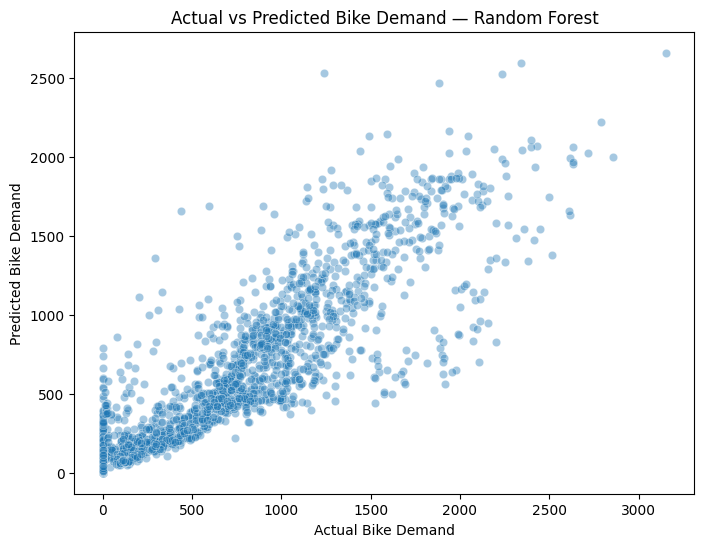

In [51]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.4
)

plt.xlabel("Actual Bike Demand")
plt.ylabel("Predicted Bike Demand")
plt.title("Actual vs Predicted Bike Demand — Random Forest")

plt.show()

In [52]:
errors = y_test - y_pred_rf

print("Mean Error:", errors.mean())
print("Maximum Error:", errors.abs().max())

Mean Error: 101.16964611872145
Maximum Error: 1404.5700000000002


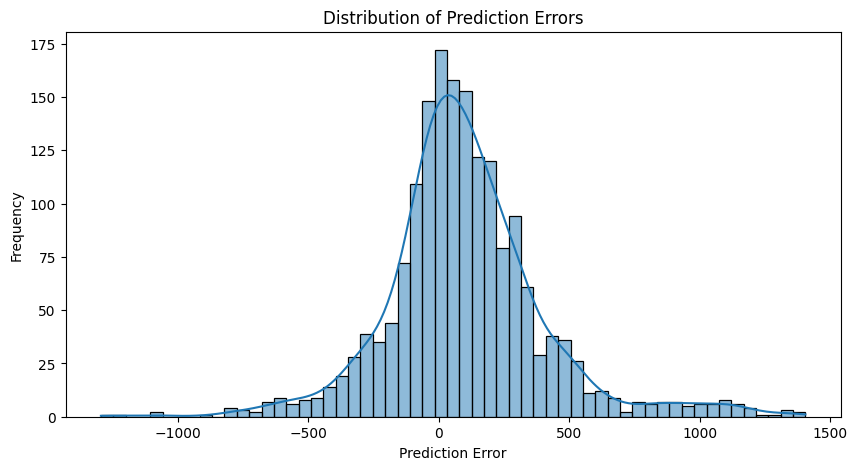

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(errors, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [54]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,num__Temperature(°C),0.381811
0,num__Hour,0.284376
6,num__Solar Radiation (MJ/m2),0.085497
2,num__Humidity(%),0.069307
7,num__Rainfall(mm),0.043550
5,num__Dew point temperature(°C),0.025361
9,num__DayOfWeek,0.020855
10,num__IsWeekend,0.013837
21,cat__Functioning Day_Yes,0.013570
11,num__Month,0.013180


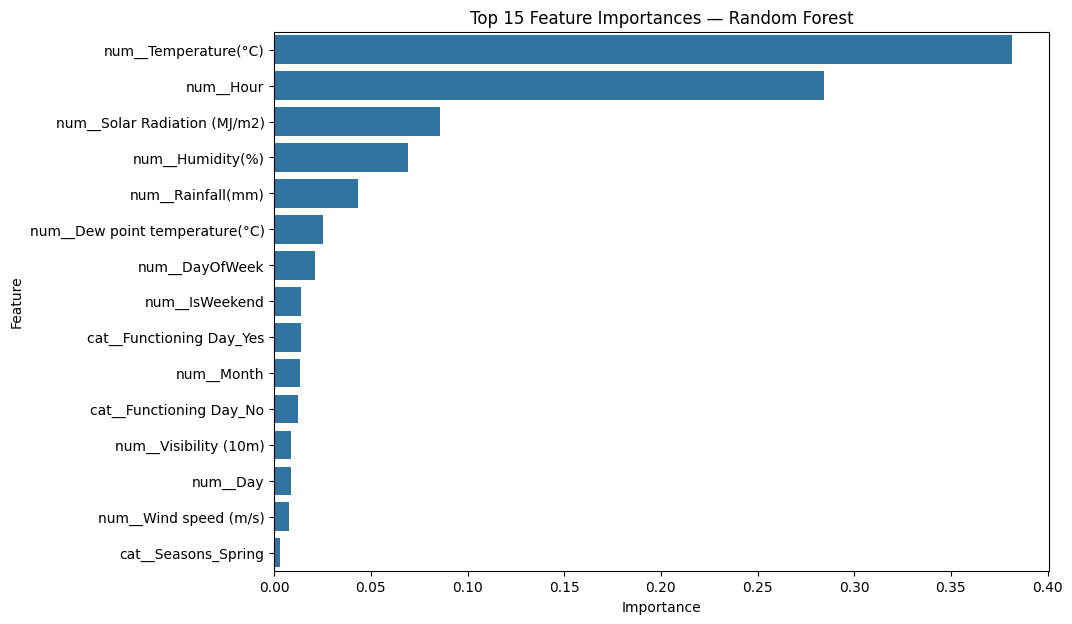

In [55]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

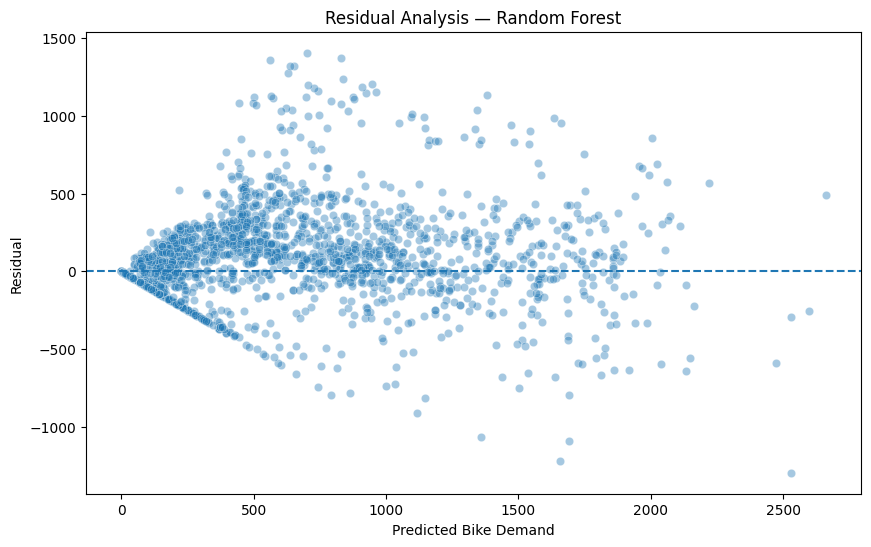

In [56]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Analysis — Random Forest")
plt.xlabel("Predicted Bike Demand")
plt.ylabel("Residual")

plt.show()

In [58]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'SeoulBikeData.csv', 'sample_data']


In [59]:
import os

print(os.path.exists("../models/bike_demand_model.pkl"))
print(os.path.exists("models/bike_demand_model.pkl"))

False
False


In [61]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file == "bike_demand_model.pkl":
            print(os.path.join(root, file))

In [62]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready")

Models folder ready


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

# Re-define categorical and numerical columns based on X_train to ensure correctness
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Create preprocessing pipeline
preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Create complete model pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessor_final),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train complete pipeline
model_pipeline.fit(X_train, y_train)

print("Final model pipeline trained successfully!")

Final model pipeline trained successfully!


In [66]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    model_pipeline,
    "../models/bike_demand_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [67]:
print(os.path.exists("../models/bike_demand_model.pkl"))

True


In [68]:
loaded_model = joblib.load(
    "../models/bike_demand_model.pkl"
)

sample_data = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_data)

print("Predicted Bike Demand:", round(prediction[0]))
print("Actual Bike Demand:", y_test.iloc[0])

Predicted Bike Demand: 12
Actual Bike Demand: 0


In [70]:
import pandas as pd
import joblib


model = joblib.load("../models/bike_demand_model.pkl")


def predict_bike_demand(input_data):
    input_data = input_data.copy()

    # Convert Date
    input_data["Date"] = pd.to_datetime(
        input_data["Date"],
        dayfirst=True
    )

    # Feature engineering
    input_data["Year"] = input_data["Date"].dt.year
    input_data["Month"] = input_data["Date"].dt.month
    input_data["Day"] = input_data["Date"].dt.day
    input_data["DayOfWeek"] = input_data["Date"].dt.dayofweek
    input_data["IsWeekend"] = (
        input_data["DayOfWeek"] >= 5
    ).astype(int)

    # Date was not used during model training
    input_data = input_data.drop(columns=["Date"])

    # Prediction
    prediction = model.predict(input_data)

    return prediction[0]

In [72]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'SeoulBikeData.csv', 'sample_data']


In [73]:
import os

os.makedirs("src", exist_ok=True)

print(os.listdir())

['.config', 'src', 'SeoulBikeData.csv', 'sample_data']


In [74]:
%%writefile src/prediction.py

import pandas as pd
import joblib

MODEL_PATH = "../models/bike_demand_model.pkl"

model = joblib.load(MODEL_PATH)


def predict_bike_demand(input_data):
    input_data = input_data.copy()

    input_data["Date"] = pd.to_datetime(
        input_data["Date"],
        dayfirst=True
    )

    input_data["Year"] = input_data["Date"].dt.year
    input_data["Month"] = input_data["Date"].dt.month
    input_data["Day"] = input_data["Date"].dt.day
    input_data["DayOfWeek"] = input_data["Date"].dt.dayofweek
    input_data["IsWeekend"] = (
        input_data["DayOfWeek"] >= 5
    ).astype(int)

    input_data = input_data.drop(columns=["Date"])

    prediction = model.predict(input_data)

    return prediction[0]

Writing src/prediction.py


In [75]:
from src.prediction import predict_bike_demand

In [76]:
from src.prediction import predict_bike_demand
import pandas as pd

In [77]:
sample_input = pd.DataFrame([{
    "Date": "15/07/2018",
    "Hour": 18,
    "Temperature(°C)": 25.0,
    "Humidity(%)": 60,
    "Wind speed (m/s)": 2.0,
    "Visibility (10m)": 1500,
    "Dew point temperature(°C)": 17.0,
    "Solar Radiation (MJ/m2)": 0.5,
    "Rainfall(mm)": 0.0,
    "Snowfall (cm)": 0.0,
    "Seasons": "Summer",
    "Holiday": "No Holiday",
    "Functioning Day": "Yes"
}])

In [78]:
prediction = predict_bike_demand(sample_input)

print("Predicted Bike Demand:", round(prediction))

Predicted Bike Demand: 2350


In [79]:
import os

print(os.path.exists("../models/bike_demand_model.pkl"))
print(os.path.exists("../src/prediction.py"))

True
False


In [80]:
import os

print("Current location:", os.getcwd())
print("Folders/files:", os.listdir())

Current location: /content
Folders/files: ['.config', 'src', 'SeoulBikeData.csv', 'sample_data']


In [81]:
os.makedirs("../src", exist_ok=True)

In [82]:
%%writefile ../src/prediction.py

import pandas as pd
import joblib

MODEL_PATH = "../models/bike_demand_model.pkl"

model = joblib.load(MODEL_PATH)


def predict_bike_demand(input_data):
    input_data = input_data.copy()

    input_data["Date"] = pd.to_datetime(
        input_data["Date"],
        dayfirst=True
    )

    input_data["Year"] = input_data["Date"].dt.year
    input_data["Month"] = input_data["Date"].dt.month
    input_data["Day"] = input_data["Date"].dt.day
    input_data["DayOfWeek"] = input_data["Date"].dt.dayofweek
    input_data["IsWeekend"] = (
        input_data["DayOfWeek"] >= 5
    ).astype(int)

    input_data = input_data.drop(columns=["Date"])

    prediction = model.predict(input_data)

    return prediction[0]

Writing ../src/prediction.py


In [83]:
print(os.path.exists("../src/prediction.py"))

True


In [84]:
from google.colab import files

files.download("../src/prediction.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
files.download("../models/bike_demand_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>